In [3]:
import pandas as pd          
import numpy as np           
import random
from datetime import datetime, timedelta
import os
random.seed(42)
np.random.seed(42)
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)
print("✅ All libraries loaded successfully!")
print(f"   pandas  version: {pd.__version__}")
print(f"   numpy   version: {np.__version__}")

✅ All libraries loaded successfully!
   pandas  version: 3.0.1
   numpy   version: 2.4.3


In [4]:
DATA_PATH = '../data/'  # Path to the data folder (where CSV files go)
CHARTS_PATH = '../charts/' # Path to the charts folder (where images go)
# Create the folders if they don't already exist.
# exist_ok=True means: if folder already exists, don't crash — just continue.
os.makedirs(DATA_PATH, exist_ok=True)
os.makedirs(CHARTS_PATH, exist_ok=True)
# Confirm it worked
print("✅ Folder paths set up successfully!")
print(f"   Data will be saved to   : {os.path.abspath(DATA_PATH)}")
print(f"   Charts will be saved to : {os.path.abspath(CHARTS_PATH)}")
# os.path.abspath() converts the relative path ("..")
# into the full path on your computer so you can see exactly where it is

✅ Folder paths set up successfully!
   Data will be saved to   : C:\Users\Sriha\Documents\pharma-pipeline-analysis\data
   Charts will be saved to : C:\Users\Sriha\Documents\pharma-pipeline-analysis\charts


In [5]:
# Define data building blocks
# ============================================================
# ── Company name parts ─────────────────────────────────────
company_prefixes = [
    "Apex", "Nexus", "Helix", "Solara", "Meridian", "Pinnacle",
    "Vantage", "Crest", "Fortis", "Lumex", "Praxis", "Syntek",
    "Orbis", "Altum", "Calibra", "Enovis", "Kinara", "Elara",
    "Centrix", "Biopharma", "Vitagen", "Clarix", "Forma", "Zenith"
]

company_suffixes = [
    "Pharma", "Healthcare", "Biotech", "Labs", "Sciences",
    "Therapeutics", "Chemicals", "Life Sciences", "Formulations",
    "Nutraceuticals", "Medical", "Biologics", "API Ltd"
]

# ── Customer sectors ───────────────────────────────────────
sectors = [
    "CDMO / Generic Manufacturer",       # Contract Drug Manufacturing Orgs — biggest buyers
    "Licensed Specials Manufacturer",    # Make bespoke medicines for specific patients
    "Hospital Pharmacy",                 # NHS and private hospital pharmacies
    "Retail Pharmacy Chain",             # Boots, Lloyds Pharmacy etc.
    "Nutraceutical Producer",            # Supplement and vitamin manufacturers
    "Contract Research Organisation"     # CROs — do drug trials, small orders
]

# ── UK + key export regions ────────────────────────────────
regions = [
    "London", "South East England", "Midlands",
    "North West England", "Yorkshire", "Scotland",
    "Wales", "Republic of Ireland", "Germany", "Netherlands"
]

# ── Products Nurogen actually sells ───────────────────────
products = [
    "Film Coating Excipients",        # Used to coat tablets (taste, stability)
    "Organic Chemicals / Binders",    # Hold tablet ingredients together
    "Oleochemicals / Lubricants",     # Stop tablets sticking to machines
    "Mixed Excipient Bundle"          # Multiple products in one order
]

# ── How leads find Nurogen ────────────────────────────────
lead_sources = [
    "LinkedIn Outreach",   # BD team contacts prospects on LinkedIn
    "Trade Show",          # CPhI, Pharmapack exhibitions
    "Referral",            # Existing customer recommends Nurogen
    "Cold Email",          # Email campaigns
    "Website Enquiry",     # Prospect fills in contact form
    "Distributor"          # Third-party distributor passes on the lead
]

# ── Pipeline stages ────────────────────────────────────────
stages = [
    "Prospect",      # Just identified — haven't contacted yet
    "Contacted",     # We've reached out, they've responded
    "Quoted",        # We've sent them a price quote
    "Negotiation",   # They're interested, discussing terms
    "Closed Won",    # Deal signed — they're now a customer! ✅
    "Closed Lost"    # They went elsewhere ❌
]

# stage_weights control how many leads appear at each stage.
# 0.20 = 20% of leads are at Prospect stage, etc.
# Notice more leads at top (Prospect/Contacted) than bottom (Won/Lost)
# — this is what a realistic funnel looks like.
stage_weights = [0.20, 0.22, 0.20, 0.14, 0.14, 0.10]

# ── Deal size ranges by sector (in £) ─────────────────────
sector_deal_ranges = {
    "CDMO / Generic Manufacturer":       (18000, 95000),
    "Licensed Specials Manufacturer":    (12000, 55000),
    "Hospital Pharmacy":                 (5000,  30000),
    "Retail Pharmacy Chain":             (8000,  40000),
    "Nutraceutical Producer":            (6000,  28000),
    "Contract Research Organisation":    (3000,  18000),
}

# Confirm everything is defined
print("✅ Data building blocks defined!")
print(f"   Sectors   : {len(sectors)}")
print(f"   Regions   : {len(regions)}")
print(f"   Products  : {len(products)}")
print(f"   Sources   : {len(lead_sources)}")
print(f"   Stages    : {len(stages)}")


✅ Data building blocks defined!
   Sectors   : 6
   Regions   : 10
   Products  : 4
   Sources   : 6
   Stages    : 6


In [6]:
# CELL 4: Generate 250 synthetic leads
# ============================================================

records = []
companies_used = set()
start_date = datetime(2023, 8, 1)   # August 1st 2023
end_date   = datetime(2024, 9, 30)  # September 30th 2024
total_days = (end_date - start_date).days

# ── THE MAIN LOOP 
for i in range(250):
    sector = random.choices(sectors, weights=[25, 18, 20, 15, 14, 8])[0]

    # Pick a region 
    region = random.choices(
        regions,
        weights=[22, 14, 12, 10, 8, 7, 5, 8, 8, 6]
    )[0]

    # Pick a product 
    product = random.choices(
        products,
        weights=[35, 30, 25, 10]
    )[0]

    # Pick how the lead was generated
    source = random.choices(
        lead_sources,
        weights=[25, 20, 18, 15, 12, 10]
    )[0]

    # Pick a pipeline stage 
    stage = random.choices(stages, weights=stage_weights)[0]

    # Generate a company name 
    company = f"{random.choice(company_prefixes)} {random.choice(company_suffixes)}"
    while company in companies_used:
        company = f"{random.choice(company_prefixes)} {random.choice(company_suffixes)}"
    companies_used.add(company)  # Mark this name as used

    # Generate deal size
    lo, hi = sector_deal_ranges[sector]
    # lo = lower bound (minimum), hi = upper bound (maximum)
    deal_size = random.uniform(lo, hi)
    deal_size = round(deal_size, -2)

    # Generate follow-up count
    follow_ups = {
        "Prospect":    0,                    # Not yet contacted
        "Contacted":   1,                    # One outreach done
        "Quoted":      2,                    # Contacted + sent quote
        "Negotiation": 3,                    # Multiple back-and-forths
        "Closed Won":  random.randint(2, 5), # Varied — some close fast
        "Closed Lost": random.randint(1, 4)  # Varied — some drag then fail
    }[stage]
    # Add 0 or 1 extra follow-up randomly — makes data feel more natural
    follow_ups += random.randint(0, 1)

    # Generate a random date 
    days_offset  = random.randint(0, total_days)
    created_date = start_date + timedelta(days=days_offset)
    

    # Generate response time
    # How many days did the prospect take to respond?
    # Later stage = more time has passed = higher response time
    response_time = {
        "Prospect":    0,
        "Contacted":   random.randint(2,  10),
        "Quoted":      random.randint(5,  20),
        "Negotiation": random.randint(10, 30),
        "Closed Won":  random.randint(15, 45),
        "Closed Lost": random.randint(8,  35)
    }[stage]

    # Generate win probability score
    base_score = {
        "Prospect":    10,
        "Contacted":   22,
        "Quoted":      40,
        "Negotiation": 62,
        "Closed Won":  100,
        "Closed Lost": 0
    }[stage]
    # Add a small random variation (-8 to +8) so scores aren't all identical
    noise      = random.randint(-8, 8)
    win_prob   = max(0, min(100, base_score + noise))
    # max(0, ...) makes sure score never goes below 0
    # min(100, ...) makes sure score never goes above 100

    # Set the outcome 
    outcome = (
        1    if stage == "Closed Won"  else
        0    if stage == "Closed Lost" else
        None  # Still in pipeline — result unknown
    )

    #  Build the row 
    record = {
        "lead_id":             f"NHC-{1000 + i}",
        # f-string: NHC-1000, NHC-1001, NHC-1002 ... NHC-1249

        "company_name":        company,
        "sector":              sector,
        "region":              region,
        "product_interest":    product,
        "lead_source":         source,
        "pipeline_stage":      stage,
        "deal_size_gbp":       deal_size,
        "follow_up_count":     follow_ups,
        "response_time_days":  response_time,
        "win_probability":     win_prob,

        "created_date": created_date.strftime("%Y-%m-%d"),

        "outcome": outcome
    }

    # Drop this row into our bucket
    records.append(record)

df = pd.DataFrame(records)
df = df.sort_values("created_date").reset_index(drop=True)

# PREVIEW THE DATA 
print("✅ Dataset generated successfully!")
print(f"\n   Total leads created : {len(df)}")
print(f"   Columns             : {len(df.columns)}")
print(f"   Date range          : {df['created_date'].min()} → {df['created_date'].max()}")

print(f"\n── Stage breakdown ──────────────────────────")
print(df['pipeline_stage'].value_counts())

print(f"\n── First 5 rows of your dataset ─────────────")
df.head()
# .head() shows the first 5 rows — always use this to sense-check your data


✅ Dataset generated successfully!

   Total leads created : 250
   Columns             : 13
   Date range          : 2023-08-05 → 2024-09-28

── Stage breakdown ──────────────────────────
pipeline_stage
Contacted      56
Negotiation    50
Quoted         49
Prospect       44
Closed Won     30
Closed Lost    21
Name: count, dtype: int64

── First 5 rows of your dataset ─────────────


,lead_id,company_name,sector,region,product_interest,lead_source,pipeline_stage,deal_size_gbp,follow_up_count,response_time_days,win_probability,created_date,outcome
0,NHC-1160,Vantage Life Sciences,Hospital Pharmacy,Scotland,Oleochemicals / Lubricants,Trade Show,Prospect,"6,900.00",0,0,17,2023-08-05,NaN
1,NHC-1212,Crest Life Sciences,Retail Pharmacy Chain,North West England,Organic Chemicals / Binders,Distributor,Negotiation,"19,100.00",3,25,56,2023-08-06,NaN
2,NHC-1164,Altum Therapeutics,Retail Pharmacy Chain,London,Oleochemicals / Lubricants,LinkedIn Outreach,Contacted,"25,500.00",1,3,15,2023-08-09,NaN
3,NHC-1224,Orbis API Ltd,CDMO / Generic Manufacturer,South East England,Film Coating Excipients,Cold Email,Closed Lost,"90,800.00",4,24,6,2023-08-13,0.00
4,NHC-1196,Syntek Biotech,Licensed Specials Manufacturer,Germany,Oleochemicals / Lubricants,LinkedIn Outreach,Quoted,"48,000.00",3,6,38,2023-08-15,NaN


In [7]:
# Save dataset to CSV
filepath = DATA_PATH + 'leads.csv'
df.to_csv(filepath, index=False)
print(f"✅ Dataset saved!")
print(f"   Location : {os.path.abspath(filepath)}")
print(f"   Rows     : {len(df)}")
print(f"   Columns  : {list(df.columns)}")
print(f"\n   Go to your data/ folder and open leads.csv in Excel")
print(f"   to visually check it looks right!")

✅ Dataset saved!
   Location : C:\Users\Sriha\Documents\pharma-pipeline-analysis\data\leads.csv
   Rows     : 250
   Columns  : ['lead_id', 'company_name', 'sector', 'region', 'product_interest', 'lead_source', 'pipeline_stage', 'deal_size_gbp', 'follow_up_count', 'response_time_days', 'win_probability', 'created_date', 'outcome']

   Go to your data/ folder and open leads.csv in Excel
   to visually check it looks right!


In [8]:
#  Exploratory Data Analysis (EDA)

print("=" * 55)
print("  EXPLORATORY DATA ANALYSIS — NUROGEN PIPELINE DATA")
print("=" * 55)

# Shape 
rows, cols = df.shape
print(f"\n📐 Shape of dataset")
print(f"   Rows    : {rows}  (each row = one lead)")
print(f"   Columns : {cols}  (each column = one field)")

  EXPLORATORY DATA ANALYSIS — NUROGEN PIPELINE DATA

📐 Shape of dataset
   Rows    : 250  (each row = one lead)
   Columns : 13  (each column = one field)


In [9]:
print("📋 Data types for each column")
print("-" * 40)
print(df.dtypes)
# .dtypes shows the data type of every column

print("\n💡 What we expect to see:")
print("   lead_id, company_name, sector etc. → object (text)")
print("   deal_size_gbp, win_probability     → float64 (decimal)")
print("   follow_up_count, response_time     → int64 (whole number)")
print("   outcome                            → float64 (because it has None values)")

📋 Data types for each column
----------------------------------------
lead_id                   str
company_name              str
sector                    str
region                    str
product_interest          str
lead_source               str
pipeline_stage            str
deal_size_gbp         float64
follow_up_count         int64
response_time_days      int64
win_probability         int64
created_date              str
outcome               float64
dtype: object

💡 What we expect to see:
   lead_id, company_name, sector etc. → object (text)
   deal_size_gbp, win_probability     → float64 (decimal)
   follow_up_count, response_time     → int64 (whole number)
   outcome                            → float64 (because it has None values)


In [10]:
# Check for missing values (nulls)


print("🔍 Missing values per column")
print("-" * 40)
missing = df.isnull().sum()
print(missing)

print(f"\n   Total missing values : {missing.sum()}")

# Calculate missing % per column
print("\n Missing value percentage per column")
print("-" * 40)
missing_pct = (df.isnull().sum() / len(df) * 100).round(1)
# len(df) = number of rows
# Dividing count by total rows gives us a percentage
for col, pct in missing_pct.items():
    if pct > 0:
        # Only print columns that actually have missing values
        print(f"   {col:<25} {pct}% missing")

print("\n The 'outcome' column SHOULD have missing values.")
print("   Leads still in the pipeline (Prospect, Contacted,")
print("   Quoted, Negotiation) don't have an outcome yet.")
print("   This is correct — not a data error.")

🔍 Missing values per column
----------------------------------------
lead_id                 0
company_name            0
sector                  0
region                  0
product_interest        0
lead_source             0
pipeline_stage          0
deal_size_gbp           0
follow_up_count         0
response_time_days      0
win_probability         0
created_date            0
outcome               199
dtype: int64

   Total missing values : 199

 Missing value percentage per column
----------------------------------------
   outcome                   79.6% missing

 The 'outcome' column SHOULD have missing values.
   Leads still in the pipeline (Prospect, Contacted,
   Quoted, Negotiation) don't have an outcome yet.
   This is correct — not a data error.


In [11]:
# Summary statistics
print("📈 Summary statistics for numeric columns")
print("-" * 55)
df.describe().round(0)

📈 Summary statistics for numeric columns
-------------------------------------------------------


,deal_size_gbp,follow_up_count,response_time_days,win_probability,outcome
count,250.00,250.00,250.00,250.00,51.00
mean,"29,456.00",2.00,13.00,39.00,1.00
std,"20,236.00",1.00,11.00,30.00,0.00
min,"3,600.00",0.00,0.00,0.00,0.00
25%,"14,800.00",1.00,4.00,15.00,0.00
50%,"23,500.00",2.00,10.00,34.00,1.00
75%,"37,275.00",3.00,18.00,59.00,1.00
max,"93,500.00",6.00,45.00,100.00,1.00


In [12]:
# Explore categorical columns

# ── Pipeline stage distribution ────────────────────────────
print("🏷️  Pipeline stage distribution")
print("-" * 45)

stage_counts = df['pipeline_stage'].value_counts()
total        = len(df)

for stage, count in stage_counts.items():
    pct  = count / total * 100
    # Build a simple text bar chart using * characters
    bar  = "█" * int(pct / 2)  # each █ = 2%
    print(f"   {stage:<30} {count:>3} leads  {pct:>5.1f}%  {bar}")

# ── Sector distribution ────────────────────────────────────
print("\n🏭  Sector distribution")
print("-" * 45)
sector_counts = df['sector'].value_counts()
for sector, count in sector_counts.items():
    pct = count / total * 100
    bar = "█" * int(pct / 2)
    print(f"   {sector:<38} {count:>3}  {pct:>5.1f}%  {bar}")

# ── Lead source distribution ───────────────────────────────
print("\n📣  Lead source distribution")
print("-" * 45)
source_counts = df['lead_source'].value_counts()
for source, count in source_counts.items():
    pct = count / total * 100
    bar = "█" * int(pct / 2)
    print(f"   {source:<25} {count:>3}  {pct:>5.1f}%  {bar}")

🏷️  Pipeline stage distribution
---------------------------------------------
   Contacted                       56 leads   22.4%  ███████████
   Negotiation                     50 leads   20.0%  ██████████
   Quoted                          49 leads   19.6%  █████████
   Prospect                        44 leads   17.6%  ████████
   Closed Won                      30 leads   12.0%  ██████
   Closed Lost                     21 leads    8.4%  ████

🏭  Sector distribution
---------------------------------------------
   CDMO / Generic Manufacturer             61   24.4%  ████████████
   Hospital Pharmacy                       58   23.2%  ███████████
   Retail Pharmacy Chain                   45   18.0%  █████████
   Licensed Specials Manufacturer          42   16.8%  ████████
   Nutraceutical Producer                  23    9.2%  ████
   Contract Research Organisation          21    8.4%  ████

📣  Lead source distribution
---------------------------------------------
   LinkedIn Outreach 

In [13]:
# Calculate key business metrics

# Filter into useful subsets 
won  = df[df['pipeline_stage'] == 'Closed Won']
lost = df[df['pipeline_stage'] == 'Closed Lost']

closed = df[df['pipeline_stage'].isin(['Closed Won', 'Closed Lost'])]
# .isin([...]) checks if a value appears in a list
# This gives us all leads that have a final outcome

active = df[~df['pipeline_stage'].isin(['Closed Won', 'Closed Lost'])]
# ~ means NOT — so this gives us all still-active leads

# ── Calculate metrics ──────────────────────────────────────
total_leads      = len(df)
total_won        = len(won)
total_lost       = len(lost)
total_closed     = len(closed)

# Win rate = won / (won + lost) — only among leads with a final outcome
# We don't include active leads here — they haven't finished yet
win_rate         = total_won / total_closed * 100

# Total revenue = sum of deal sizes for won deals only
total_revenue    = won['deal_size_gbp'].sum()

# Average deal size among won deals
avg_deal_won     = won['deal_size_gbp'].mean()

# Total pipeline value = sum of ALL deal sizes (won + active)
# This represents potential future revenue
total_pipeline   = active['deal_size_gbp'].sum()

# Best performing lead source (by revenue generated)
best_source      = won.groupby('lead_source')['deal_size_gbp'].sum().idxmax()
# .groupby() groups rows by a column
# .sum() totals the deal sizes within each group
# .idxmax() returns the name of the group with the highest total

# Best performing sector (by revenue generated)
best_sector      = won.groupby('sector')['deal_size_gbp'].sum().idxmax()

print("=" * 55)
print("  KEY BUSINESS METRICS — NUROGEN HEALTHCARE")
print("=" * 55)
print(f"\n  📌 Pipeline overview")
print(f"     Total leads         : {total_leads}")
print(f"     Active leads        : {len(active)}")
print(f"     Closed Won          : {total_won}")
print(f"     Closed Lost         : {total_lost}")

print(f"\n  💰 Revenue & pipeline")
print(f"     Win rate            : {win_rate:.1f}%")
print(f"     Total revenue       : £{total_revenue:,.0f}")
print(f"     Average deal (won)  : £{avg_deal_won:,.0f}")
print(f"     Active pipeline     : £{total_pipeline:,.0f}")

print(f"\n  🏆 Top performers")
print(f"     Best lead source    : {best_source}")
print(f"     Best sector         : {best_sector}")

print(f"\n💡 Interpretation:")
print(f"   A {win_rate:.0f}% win rate is {'strong' if win_rate > 60 else 'typical'} for B2B pharma supply.")
print(f"   Your active pipeline of £{total_pipeline:,.0f} represents")
print(f"   potential future revenue if those leads convert.")

  KEY BUSINESS METRICS — NUROGEN HEALTHCARE

  📌 Pipeline overview
     Total leads         : 250
     Active leads        : 199
     Closed Won          : 30
     Closed Lost         : 21

  💰 Revenue & pipeline
     Win rate            : 58.8%
     Total revenue       : £733,100
     Average deal (won)  : £24,437
     Active pipeline     : £6,017,500

  🏆 Top performers
     Best lead source    : Distributor
     Best sector         : CDMO / Generic Manufacturer

💡 Interpretation:
   A 59% win rate is typical for B2B pharma supply.
   Your active pipeline of £6,017,500 represents
   potential future revenue if those leads convert.


In [14]:
# Import chart libraries and set global style

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# Colour palette 
C_PURPLE = "#7F77DD"   # main colour — used for primary bars
C_TEAL   = "#1D9E75"   # positive/success colour
C_AMBER  = "#EF9F27"   # warning/mid colour
C_CORAL  = "#D85A30"   # accent/highlight colour
C_GRAY   = "#888780"   # neutral/secondary colour
C_LIGHT  = "#F5F4F0"   # background tint

# Global chart style
plt.rcParams.update({
    "font.family":       "DejaVu Sans",  # clean, readable font
    "font.size":         11,             # base font size
    "axes.spines.top":   False,          # remove top border line
    "axes.spines.right": False,          # remove right border line
    # Removing top/right borders is modern chart design practice
    # It reduces visual clutter and looks more professional
    "axes.grid":         True,           # show gridlines
    "grid.alpha":        0.3,            # gridlines at 30% opacity (subtle)
    "grid.linestyle":    "--",           # dashed gridlines
    "figure.facecolor":  "white",        # white chart background
    "axes.facecolor":    "white",        # white plot area background
    "axes.titlepad":     14,             # space between title and chart
})

# Helper function for £ axis labels
def gbp_formatter(x, pos):
    # x = the raw number on the axis
    # pos = position (we don't use this but it's required)
    return f"£{x/1000:.0f}k"
    # x/1000 converts 30000 → 30
    # :.0f means show 0 decimal places
    # So 30000 becomes "£30k"

print(" Chart libraries loaded and style set!")
print(f"   Colours defined  : 5")
print(f"   Style settings   : clean, white background, no top/right borders")
print(f"   Ready to build   : 4 charts")

 Chart libraries loaded and style set!
   Colours defined  : 5
   Style settings   : clean, white background, no top/right borders
   Ready to build   : 4 charts


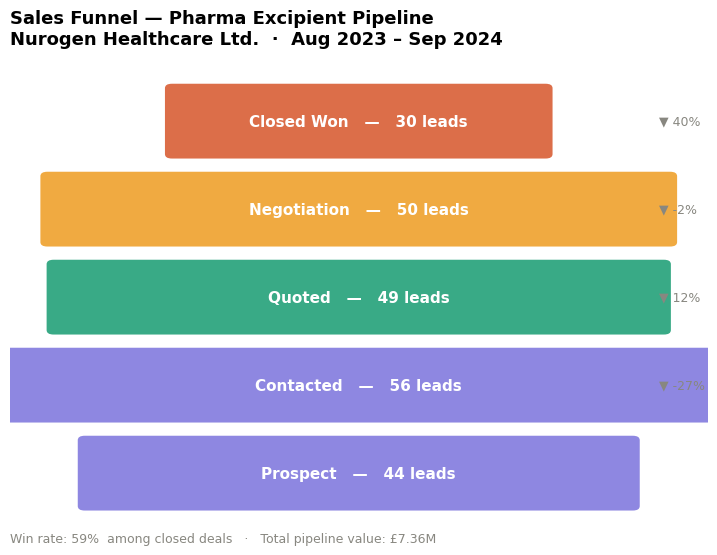


✅ Chart 1 saved to: C:\Users\Sriha\Documents\pharma-pipeline-analysis\charts\chart1_funnel.png

💡 What this chart tells us:
   The biggest drop-off is between Quoted → Negotiation.
   This suggests price or MOQ is a friction point.
   Recommendation: consider a smaller trial order option.


In [15]:
# Chart 1 — Sales Funnel


# Prepare the data 
funnel_stages = ["Prospect", "Contacted", "Quoted",
                 "Negotiation", "Closed Won"]

# Count how many leads are at each stage, in our chosen order
funnel_counts = [
    df[df['pipeline_stage'] == stage].shape[0]
    for stage in funnel_stages
    
]

dropoffs = []
for i in range(1, len(funnel_counts)):
    # range(1, 5) = [1, 2, 3, 4] — we start at 1 to compare with previous
    prev    = funnel_counts[i - 1]  # stage before
    current = funnel_counts[i]      # current stage
    drop    = (prev - current) / prev * 100
    dropoffs.append(drop)

# Win rate (among leads with a final decision)
total_closed = len(won) + len(lost)
win_rate     = len(won) / total_closed * 100

# Build the chart 
fig, ax = plt.subplots(figsize=(9, 6))
# fig = the whole figure (like a canvas)
# ax  = the axes (the actual chart area)
# figsize=(9,6) = 9 inches wide, 6 inches tall

# The maximum count (top of funnel) = our reference for bar widths
max_count = max(funnel_counts)

# Colours: start purple, end coral (warmer = closer to winning)
bar_colours = [C_PURPLE, C_PURPLE, C_TEAL, C_AMBER, C_CORAL]

# Draw one bar per stage
for i, (stage, count) in enumerate(zip(funnel_stages, funnel_counts)):
    # zip() pairs each stage with its count: ("Prospect", 49), etc.
    # enumerate() adds an index i: 0, 1, 2, 3, 4

    # Bar width as a proportion of the maximum
    # e.g. if max=55 and count=37: proportion = 37/55 = 0.67
    proportion = count / max_count

    # Centre the bar horizontally
    # If proportion=0.67: bar starts at (1-0.67)/2 = 0.165
    #                     bar ends at   0.165 + 0.67 = 0.835
    x_start = (1 - proportion) / 2
    y_pos   = i * 0.20  # vertical position for this bar (spaced 0.20 apart)

    # Draw the bar using FancyBboxPatch (a rectangle with rounded corners)
    rect = mpatches.FancyBboxPatch(
        (x_start, y_pos),           # (x, y) starting corner
        proportion,                  # width
        0.15,                        # height of each bar
        boxstyle="round,pad=0.01",  # slightly rounded corners
        facecolor=bar_colours[i],   # fill colour
        alpha=0.88,                 # slight transparency
        linewidth=0                 # no border line
    )
    ax.add_patch(rect)  # add the shape to the chart

    # Label inside the bar: "Stage Name  —  37 leads"
    ax.text(
        0.5,                          # x = centre of chart
        y_pos + 0.075,                # y = middle of this bar
        f"{stage}   —   {count} leads",
        ha="center",                  # horizontal alignment = centre
        va="center",                  # vertical alignment = centre
        fontsize=11,
        color="white",
        fontweight="bold"
    )

    # Drop-off label on the right side (except for first bar)
    if i > 0:
        drop = dropoffs[i - 1]
        ax.text(
            0.93,               # x = right side
            y_pos + 0.075,      # y = middle of this bar
            f"▼ {drop:.0f}%",   # e.g. "▼ 29%"
            ha="left",
            va="center",
            fontsize=9,
            color=C_GRAY
        )

# Chart formatting 
ax.set_xlim(0, 1)
ax.set_ylim(-0.05, len(funnel_stages) * 0.20)
ax.axis("off")
# axis("off") hides the x and y axis lines and labels
# We don't need them — the bars speak for themselves

# Title
ax.set_title(
    "Sales Funnel — Pharma Excipient Pipeline\n"
    "Nurogen Healthcare Ltd.  ·  Aug 2023 – Sep 2024",
    fontsize=13,
    fontweight="bold",
    loc="left",   # align title to the left (modern style)
    pad=16
)

# Summary line at the bottom
ax.text(
    0.0, -0.03,
    f"Win rate: {win_rate:.0f}%  among closed deals   "
    f"·   Total pipeline value: £{df['deal_size_gbp'].sum()/1e6:.2f}M",
    fontsize=9,
    color=C_GRAY,
    transform=ax.transAxes
    # transAxes means coordinates are 0–1 relative to the chart
    # not the actual data values
)

# ── Save the chart ─────────────────────────────────────────
chart1_path = CHARTS_PATH + 'chart1_funnel.png'
plt.savefig(
    chart1_path,
    dpi=150,          # dpi = dots per inch — 150 gives sharp, clear images
    bbox_inches="tight"  # crops whitespace around the chart edges
)
plt.show()
# plt.show() displays the chart directly in Jupyter below the cell

print(f"\n✅ Chart 1 saved to: {os.path.abspath(chart1_path)}")
print(f"\n💡 What this chart tells us:")
print(f"   The biggest drop-off is between Quoted → Negotiation.")
print(f"   This suggests price or MOQ is a friction point.")
print(f"   Recommendation: consider a smaller trial order option.")

In [16]:
# Chart 2 — Monthly Lead Volume & Pipeline Value

# Prepare the data 
df['created_date'] = pd.to_datetime(df['created_date'])
# pd.to_datetime() converts text like "2023-08-15"
# into a real datetime object pandas can work with

# Extract the month-year period from each date
# e.g. "2023-08-15" → "2023-08"
df['month'] = df['created_date'].dt.to_period('M')
# .dt = the datetime accessor (lets us extract date parts)
# .to_period('M') = convert to month period
# 'M' stands for Month

# Group by month and calculate two things:
# 1. How many leads were created each month (count)
# 2. Total pipeline value each month (sum of deal sizes)
monthly = df.groupby('month').agg(
    lead_count     = ('lead_id',       'count'),
    pipeline_value = ('deal_size_gbp', 'sum')
).reset_index()
# .agg() = aggregate — apply multiple functions at once
# 'lead_id', 'count' = count how many lead_ids per month
# 'deal_size_gbp', 'sum' = sum all deal sizes per month
# reset_index() turns month back into a regular column

# Convert month period to readable text for axis labels
# e.g. Period('2023-08') → "Aug 23"
monthly['month_label'] = monthly['month'].dt.strftime('%b %y')
# .strftime('%b %y') = short month name + 2-digit year
# %b = abbreviated month (Aug, Sep, Oct...)
# %y = 2-digit year (23, 24)

print("Monthly data prepared:")
print(monthly[['month_label', 'lead_count', 'pipeline_value']].to_string(index=False))
# .to_string(index=False) prints the table without row numbers

Monthly data prepared:
month_label  lead_count  pipeline_value
     Aug 23          13      406,400.00
     Sep 23          12      481,100.00
     Oct 23          10      245,200.00
     Nov 23          19      575,000.00
     Dec 23          23      718,300.00
     Jan 24          19      445,700.00
     Feb 24          19      639,300.00
     Mar 24          24      655,500.00
     Apr 24          23      757,200.00
     May 24          14      355,100.00
     Jun 24          17      587,300.00
     Jul 24          25      556,800.00
     Aug 24          11      335,500.00
     Sep 24          21      605,700.00


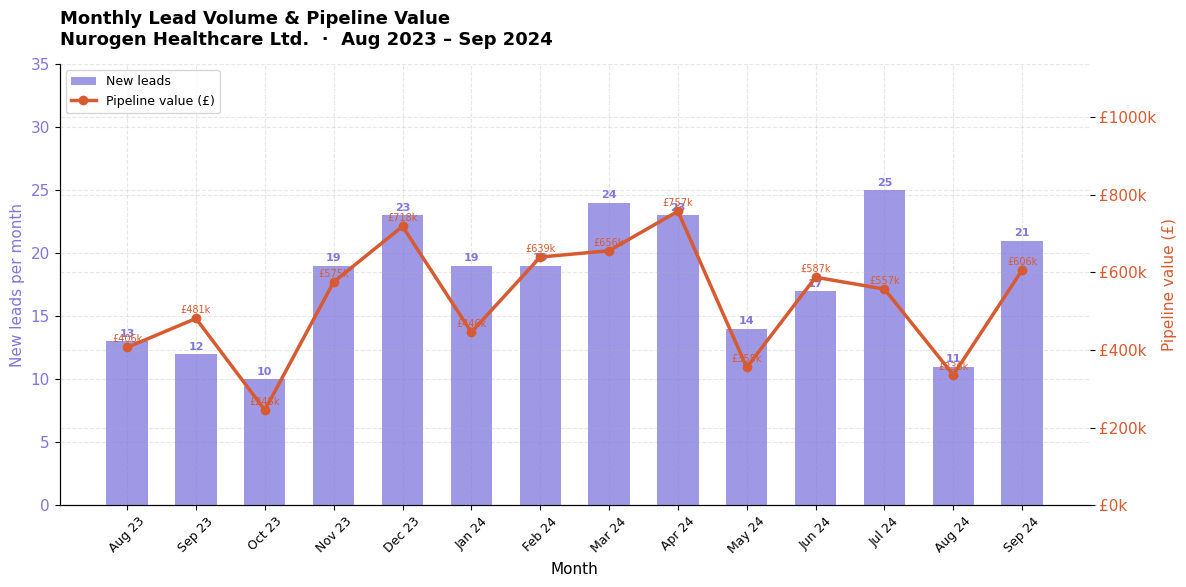


✅ Chart 2 saved!

💡 What to look for in this chart:
   Peaks in lead volume — when was BD most active?
   Do high lead months also have high pipeline value?
   Or do some months have few leads but large deal sizes?

   Busiest month (most leads)    : Jul 24
   Highest value month           : Apr 24
   → Different months — worth investigating why.
     High volume ≠ high value always.
     Quality of leads matters as much as quantity.


In [17]:
# Build the chart 

# Create a figure with ONE set of axes (ax1)
fig, ax1 = plt.subplots(figsize=(12, 6))
# figsize=(12,6) — wider than usual to fit 14 monthly labels

# Create a SECOND Y axis that shares the same X axis
# twinx() = "twin x" — same x axis, new y axis on the right
ax2 = ax1.twinx()

# ── Draw the bars (lead count) on ax1 ─────────────────────
# x = month labels (text), y = number of leads
bars = ax1.bar(
    monthly['month_label'],    # x axis = month names
    monthly['lead_count'],     # y axis = lead count
    color=C_PURPLE,            # our purple colour
    alpha=0.75,                # 75% opacity — slightly transparent
    width=0.6,                 # bar width (0-1 scale)
    label='New leads',         # label for the legend
    zorder=3                   # zorder controls layering
                               # higher number = drawn on top
)

# Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()  # get the bar's height value
    ax1.text(
        bar.get_x() + bar.get_width() / 2,  # x = centre of bar
        height + 0.2,                        # y = just above bar
        str(int(height)),                    # label = the number
        ha='center',
        va='bottom',
        fontsize=8,
        color=C_PURPLE,
        fontweight='bold'
    )

# ── Draw the line (pipeline value) on ax2 ─────────────────
ax2.plot(
    monthly['month_label'],         # x axis = same month names
    monthly['pipeline_value'],      # y axis = total £ value
    color=C_CORAL,                  # coral colour for the line
    linewidth=2.5,                  # line thickness
    marker='o',                     # 'o' = circle marker at each point
    markersize=6,                   # size of the circles
    label='Pipeline value (£)',     # label for legend
    zorder=4                        # drawn on top of bars
)

# Add value labels next to each data point on the line
for x, y in zip(monthly['month_label'], monthly['pipeline_value']):
    ax2.text(
        x,                          # x = month label
        y + 8000,                   # y = slightly above the point
        f"£{y/1000:.0f}k",         # format as £XXXk
        ha='center',
        va='bottom',
        fontsize=7,
        color=C_CORAL
    )

# ── Format the LEFT Y axis (lead count) ───────────────────
ax1.set_ylabel('New leads per month', color=C_PURPLE, fontsize=11)
ax1.tick_params(axis='y', labelcolor=C_PURPLE)
# tick_params controls the appearance of axis tick marks and labels
ax1.set_ylim(0, monthly['lead_count'].max() * 1.4)
# Set y limit 40% above max value — creates space for bar labels

# ── Format the RIGHT Y axis (pipeline value) ──────────────
ax2.set_ylabel('Pipeline value (£)', color=C_CORAL, fontsize=11)
ax2.tick_params(axis='y', labelcolor=C_CORAL)
ax2.yaxis.set_major_formatter(FuncFormatter(gbp_formatter))
# Apply our custom £XXk formatter to the right axis
ax2.set_ylim(0, monthly['pipeline_value'].max() * 1.5)
# Extra space for the value labels above the line points

# ── Format the X axis ─────────────────────────────────────
ax1.tick_params(axis='x', rotation=45, labelsize=9)
# rotation=45 tilts the month labels so they don't overlap
ax1.set_xlabel('Month', fontsize=11)

# ── Add gridlines (only horizontal, only on ax1) ──────────
ax1.yaxis.grid(True, alpha=0.3, linestyle='--')
ax1.set_axisbelow(True)
# set_axisbelow(True) puts gridlines behind the bars

# ── Remove top/right borders ──────────────────────────────
ax1.spines['top'].set_visible(False)
# We keep ax2's right spine (it's the right Y axis line)

# ── Build the legend ──────────────────────────────────────
# We need to combine legends from both axes into one
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
# get_legend_handles_labels() returns the coloured symbols and text
ax1.legend(
    lines1 + lines2,    # combine both sets of symbols
    labels1 + labels2,  # combine both sets of labels
    loc='upper left',   # position the legend top-left
    fontsize=9,
    framealpha=0.8      # slight transparency on legend background
)

# ── Title ──────────────────────────────────────────────────
ax1.set_title(
    'Monthly Lead Volume & Pipeline Value\n'
    'Nurogen Healthcare Ltd.  ·  Aug 2023 – Sep 2024',
    fontsize=13,
    fontweight='bold',
    loc='left'
)

# ── Save ───────────────────────────────────────────────────
plt.tight_layout()
# tight_layout() automatically adjusts spacing so nothing overlaps
# Always call this before saving

chart2_path = CHARTS_PATH + 'chart2_monthly_trend.png'
plt.savefig(chart2_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Chart 2 saved!")
print(f"\n💡 What to look for in this chart:")
print(f"   Peaks in lead volume — when was BD most active?")
print(f"   Do high lead months also have high pipeline value?")
print(f"   Or do some months have few leads but large deal sizes?")

# ── Key insight calculation ────────────────────────────────
best_month_leads = monthly.loc[monthly['lead_count'].idxmax(), 'month_label']
best_month_value = monthly.loc[monthly['pipeline_value'].idxmax(), 'month_label']

print(f"\n   Busiest month (most leads)    : {best_month_leads}")
print(f"   Highest value month           : {best_month_value}")

if best_month_leads == best_month_value:
    print(f"   → Same month! Volume and value aligned that month.")
else:
    print(f"   → Different months — worth investigating why.")
    print(f"     High volume ≠ high value always.")
    print(f"     Quality of leads matters as much as quantity.")

In [18]:
# Chart 3 — Sector Performance

#Prepare the data

closed_deals = df[df['pipeline_stage'].isin(['Closed Won', 'Closed Lost'])]
# .isin() checks if value is in the list — returns True/False per row

# Group by sector and calculate metrics for each group
sector_stats = closed_deals.groupby('sector').apply(
    lambda g: pd.Series({

        # Win rate = how many deals in this group were Won?
        # (g['pipeline_stage'] == 'Closed Won') creates True/False column
        # .mean() on True/False = proportion of True values
        # * 100 converts proportion to percentage
        'win_rate': (g['pipeline_stage'] == 'Closed Won').mean() * 100,

        # Average deal size — but only for WON deals
        # We filter to won deals first, then take the mean
        # If no won deals in a sector, this returns NaN
        'avg_deal': g.loc[
            g['pipeline_stage'] == 'Closed Won', 'deal_size_gbp'
        ].mean(),

        # How many total closed deals in this sector?
        # Useful context for understanding the win rate
        'total_closed': len(g),

        # How many were won?
        'total_won': (g['pipeline_stage'] == 'Closed Won').sum()
    })
).reset_index()
# reset_index() turns sector back into a regular column

# Sort by win rate so highest appears at top of chart
# ascending=True because horizontal bars read bottom to top
sector_stats = sector_stats.sort_values('win_rate', ascending=True)

# Shorter display names — full names are too long for chart labels
short_names = {
    'CDMO / Generic Manufacturer':      'CDMO / Generic',
    'Licensed Specials Manufacturer':   'Licensed Specials',
    'Hospital Pharmacy':                'Hospital Pharmacy',
    'Retail Pharmacy Chain':            'Retail Pharmacy',
    'Nutraceutical Producer':           'Nutraceuticals',
    'Contract Research Organisation':   'CRO'
}
sector_stats['label'] = sector_stats['sector'].map(short_names)
# .map() replaces each value using the dictionary as a lookup table

print("Sector statistics prepared:")
print(sector_stats[['label', 'win_rate', 'avg_deal',
                     'total_closed', 'total_won']].to_string(index=False))

Sector statistics prepared:
            label  win_rate  avg_deal  total_closed  total_won
  Retail Pharmacy     42.86 20,333.33          7.00       3.00
   CDMO / Generic     45.45 51,840.00         11.00       5.00
Hospital Pharmacy     63.64 15,300.00         11.00       7.00
Licensed Specials     66.67 28,850.00          9.00       6.00
   Nutraceuticals     66.67 18,925.00          6.00       4.00
              CRO     71.43 11,400.00          7.00       5.00


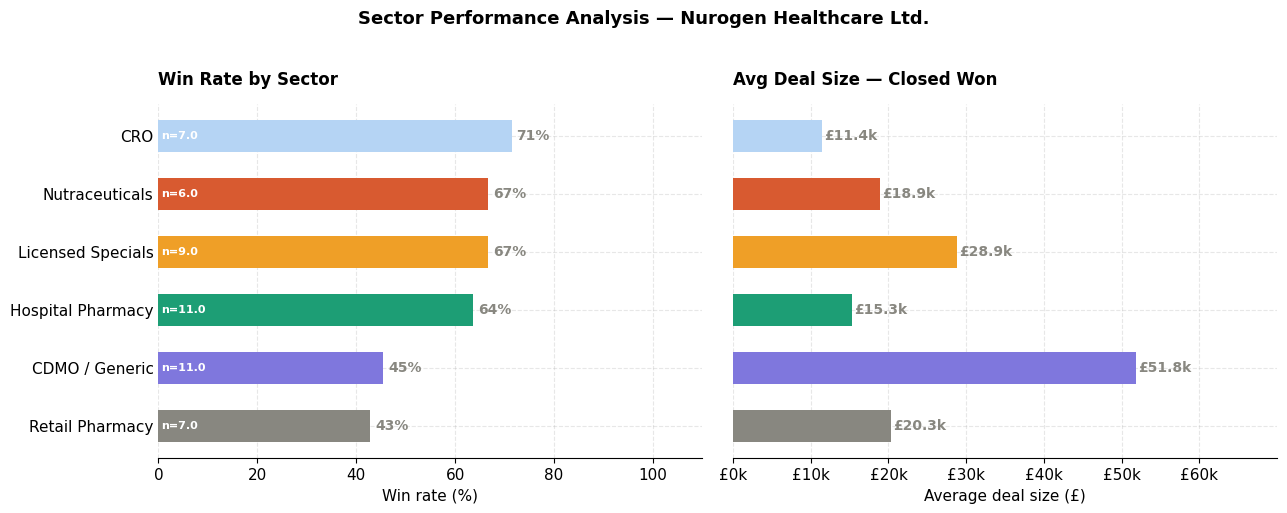


✅ Chart 3 saved!

💡 Key insights from this chart:
   Highest win rate  : CRO (71%)
   Highest avg deal  : CDMO / Generic (£51,840)

   Strategic recommendation:
   Focus BD effort on sectors with BOTH
   high win rate AND high average deal size.
   These give the best return per hour of BD time.


In [20]:
# Build the side-by-side charts

# Create figure with 2 side-by-side chart areas
fig, (ax1, ax2) = plt.subplots(
    1, 2,              # 1 row, 2 columns
    figsize=(13, 5),   # wide figure to fit both charts
    sharey=True        # sharey=True means both charts share
                       # the same Y axis labels (sector names)
                       # so we don't repeat them twice
)

# ── Assign a colour to each sector ────────────────────────
# We create a list of colours — one per sector row
# Using our defined palette in a logical order
sector_colours = [C_GRAY, C_PURPLE, C_TEAL, C_AMBER, C_CORAL, "#B5D4F4"]
# One colour per sector (6 sectors, 6 colours)

# ── LEFT CHART: Win Rate ───────────────────────────────────
bars1 = ax1.barh(
    sector_stats['label'],     # y axis = sector names
    sector_stats['win_rate'],  # x axis = win rate %
    color=sector_colours,      # different colour per sector
    edgecolor='none',          # no border on bars
    height=0.55                # bar thickness (0-1)
)
# barh = horizontal bar chart
# Regular bar() = vertical bars
# barh() = horizontal bars (better for long category names)

# Add percentage labels at the end of each bar
for bar, val in zip(bars1, sector_stats['win_rate']):
    ax1.text(
        val + 1,                         # x = just past end of bar
        bar.get_y() + bar.get_height()/2, # y = middle of bar
        f'{val:.0f}%',                   # label text e.g. "67%"
        va='center',
        fontsize=10,
        fontweight='bold',
        color=C_GRAY
    )

# Add sample size in brackets on the left
for bar, row in zip(bars1, sector_stats.itertuples()):
    ax1.text(
        0.5,                              # x = near left edge
        bar.get_y() + bar.get_height()/2, # y = middle of bar
        f'n={row.total_closed}',          # e.g. "n=15"
        va='center',
        ha='left',
        fontsize=8,
        color='white',
        fontweight='bold'
        # White text on the coloured bar
    )

# Format left chart
ax1.set_xlabel('Win rate (%)', fontsize=11)
ax1.set_title('Win Rate by Sector', fontsize=12,
              fontweight='bold', loc='left')
ax1.set_xlim(0, 110)
# xlim goes to 110 to leave room for the % labels
ax1.xaxis.grid(True, alpha=0.3, linestyle='--')
ax1.set_axisbelow(True)
ax1.tick_params(axis='y', length=0)
# length=0 removes the tick marks on y axis (cleaner look)
ax1.spines['left'].set_visible(False)
# Remove left border line — modern chart style

# ── RIGHT CHART: Average Deal Size ────────────────────────

# Drop rows where avg_deal is NaN
# (sectors with no won deals have no average to show)
valid_stats = sector_stats.dropna(subset=['avg_deal'])

bars2 = ax2.barh(
    valid_stats['label'],    # y axis = sector names
    valid_stats['avg_deal'], # x axis = average deal in £
    color=sector_colours[:len(valid_stats)],
    edgecolor='none',
    height=0.55
)

# Add £ value labels at end of each bar
for bar, val in zip(bars2, valid_stats['avg_deal']):
    ax2.text(
        val + 300,                        # x = just past bar end
        bar.get_y() + bar.get_height()/2, # y = middle of bar
        f'£{val/1000:.1f}k',             # e.g. "£42.3k"
        va='center',
        fontsize=10,
        fontweight='bold',
        color=C_GRAY
    )

# Format right chart
ax2.set_xlabel('Average deal size (£)', fontsize=11)
ax2.set_title('Avg Deal Size — Closed Won', fontsize=12,
              fontweight='bold', loc='left')
ax2.xaxis.set_major_formatter(FuncFormatter(gbp_formatter))
# Apply our £XXk formatter to the x axis
ax2.xaxis.grid(True, alpha=0.3, linestyle='--')
ax2.set_axisbelow(True)
ax2.tick_params(axis='y', length=0)
ax2.spines['left'].set_visible(False)
ax2.set_xlim(0, valid_stats['avg_deal'].max() * 1.35)
# 35% extra space for value labels

# ── Overall title across both charts ──────────────────────
fig.suptitle(
    'Sector Performance Analysis — Nurogen Healthcare Ltd.',
    fontsize=13,
    fontweight='bold',
    y=1.02   # y=1.02 places title slightly above the charts
)

# ── Save ───────────────────────────────────────────────────
plt.tight_layout()
chart3_path = CHARTS_PATH + 'chart3_sector_performance.png'
plt.savefig(chart3_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Chart 3 saved!")

# ── Key insights ───────────────────────────────────────────
top_winrate = sector_stats.iloc[-1]
# iloc[-1] = last row (highest win rate after sorting ascending)

top_value   = sector_stats.dropna(
    subset=['avg_deal']
).sort_values('avg_deal').iloc[-1]

print(f"\n💡 Key insights from this chart:")
print(f"   Highest win rate  : {top_winrate['label']}"
      f" ({top_winrate['win_rate']:.0f}%)")
print(f"   Highest avg deal  : {top_value['label']}"
      f" (£{top_value['avg_deal']:,.0f})")

print(f"\n   Strategic recommendation:")
print(f"   Focus BD effort on sectors with BOTH")
print(f"   high win rate AND high average deal size.")
print(f"   These give the best return per hour of BD time.")

In [21]:
# Chart 4 — Deal Size Distribution by Product

#  Prepare the data ───────────────────────────────

# Get the 4 unique product types in our dataset
products_in_data = df['product_interest'].unique()
# .unique() returns an array of unique values — no duplicates
print(f"Products in dataset: {products_in_data}")

# Calculate median deal size per product
# We'll use this to sort products and add reference lines
product_medians = df.groupby('product_interest')['deal_size_gbp'].median()
# groupby + median = middle value of deal sizes per product

# Sort products by median deal size (highest first)
product_medians = product_medians.sort_values(ascending=False)

print(f"\nMedian deal size by product:")
for product, median in product_medians.items():
    print(f"   {product:<35} £{median:,.0f}")

Products in dataset: <StringArray>
[ 'Oleochemicals / Lubricants', 'Organic Chemicals / Binders',
     'Film Coating Excipients',      'Mixed Excipient Bundle']
Length: 4, dtype: str

Median deal size by product:
   Organic Chemicals / Binders         £24,800
   Film Coating Excipients             £24,700
   Oleochemicals / Lubricants          £21,300
   Mixed Excipient Bundle              £20,850


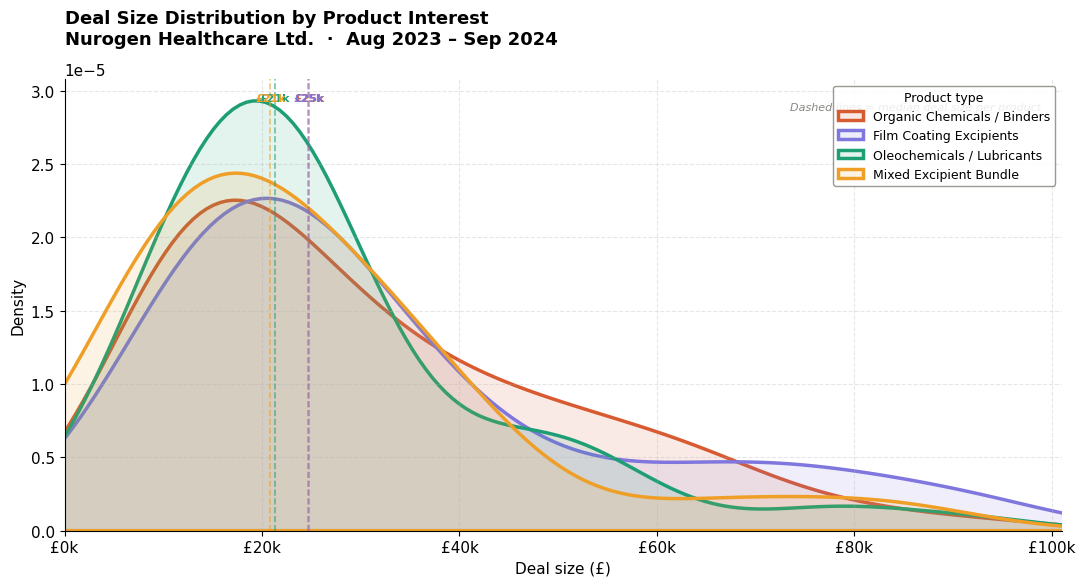


✅ Chart 4 saved!

💡 Key insights from this chart:
   Highest median deal  : Organic Chemicals / Binders
                          £24,800
   Lowest median deal   : Mixed Excipient Bundle
                          £20,850
   Most variable product: Film Coating Excipients
   (widest spread = hardest to forecast revenue from)

   What this means for Nurogen:
   Products with tall narrow peaks generate
   consistent, predictable revenue — easier to plan around.
   Products with flat wide curves are higher risk —
   some deals are huge, others tiny.


In [22]:
# Build the KDE chart

fig, ax = plt.subplots(figsize=(11, 6))

# Assign one colour to each product — consistent across chart
product_colours = {
    product: colour
    for product, colour in zip(
        product_medians.index,         # product names (sorted by median)
        [C_CORAL, C_PURPLE, C_TEAL, C_AMBER]  # one colour each
    )
}
# This is a "dictionary comprehension" — like a list comprehension
# but creates a dictionary instead.
# zip() pairs each product with a colour.
# Result: {"Film Coating Excipients": "#D85A30", ...}

# ── Draw one KDE curve per product ────────────────────────
for product in product_medians.index:
    # Filter data to just this product's deals
    product_data = df[df['product_interest'] == product]['deal_size_gbp']
    # df[condition] filters rows, then ['deal_size_gbp'] gets that column

    colour = product_colours[product]

    # Draw the KDE curve
    sns.kdeplot(
        data=product_data,       # the deal size values
        ax=ax,                   # which chart area to draw on
        color=colour,            # line colour
        linewidth=2.5,           # line thickness
        fill=True,               # shade the area under the curve
        alpha=0.12,              # shading opacity (very transparent)
        label=product            # text for the legend
    )
    # fill=True + alpha=0.12 creates a subtle shaded area
    # The low alpha means 4 overlapping shaded areas don't
    # turn into one dark blob — they stay readable

    # Draw a vertical dashed line at the median
    median_val = product_medians[product]
    ax.axvline(
        x=median_val,            # x position = median value
        color=colour,            # same colour as the curve
        linestyle='--',          # dashed line
        linewidth=1.2,
        alpha=0.6                # slightly transparent
    )
    # axvline = "axis vertical line"
    # These dashed lines make it easy to compare medians
    # across products at a glance

    # Add a label at the top of each median line
    # First we need the y position — get the max height of the chart
    # We do this after all curves are drawn (see below)

# ── Format the X axis ─────────────────────────────────────
ax.xaxis.set_major_formatter(FuncFormatter(gbp_formatter))
# Apply our £XXk formatter so axis shows £10k, £20k etc.

ax.set_xlim(0, df['deal_size_gbp'].max() * 1.08)
# Set x limit slightly beyond max deal size
# 1.08 = 8% extra space on the right

# ── Add median labels above each dashed line ──────────────
# Now that all curves are drawn, we know the y axis range
y_max = ax.get_ylim()[1]
# get_ylim() returns (min, max) of y axis
# [1] gets the max value

for product in product_medians.index:
    median_val = product_medians[product]
    colour     = product_colours[product]

    ax.text(
        median_val,              # x = at the median line
        y_max * 0.97,            # y = near the top of the chart
        f'£{median_val/1000:.0f}k',  # label e.g. "£24k"
        ha='center',
        va='top',
        fontsize=8,
        color=colour,
        fontweight='bold',
        rotation=0
    )

# ── Axis labels ────────────────────────────────────────────
ax.set_xlabel('Deal size (£)', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
# Density = how concentrated deals are at each price point
# Higher density = more deals at that size

# ── Add an explanatory annotation ─────────────────────────
ax.text(
    0.98, 0.95,                  # position (98% across, 95% up)
    'Dashed lines = median deal size per product',
    transform=ax.transAxes,      # coordinates relative to chart
    ha='right',                  # align to right
    va='top',
    fontsize=8,
    color=C_GRAY,
    style='italic'
)

# ── Legend ────────────────────────────────────────────────
ax.legend(
    title='Product type',        # legend heading
    title_fontsize=9,
    fontsize=9,
    loc='upper right',
    framealpha=0.85,
    edgecolor=C_GRAY
)

# ── Title ──────────────────────────────────────────────────
ax.set_title(
    'Deal Size Distribution by Product Interest\n'
    'Nurogen Healthcare Ltd.  ·  Aug 2023 – Sep 2024',
    fontsize=13,
    fontweight='bold',
    loc='left'
)

# ── Save ───────────────────────────────────────────────────
plt.tight_layout()
chart4_path = CHARTS_PATH + 'chart4_deal_distribution.png'
plt.savefig(chart4_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Chart 4 saved!")

# ── Key insights ───────────────────────────────────────────
highest_median = product_medians.index[0]
lowest_median  = product_medians.index[-1]
widest_spread  = df.groupby('product_interest')['deal_size_gbp'].std().idxmax()
# .std() = standard deviation = measure of how spread out values are
# .idxmax() = which product has the highest spread

print(f"\n💡 Key insights from this chart:")
print(f"   Highest median deal  : {highest_median}")
print(f"                          £{product_medians.iloc[0]:,.0f}")
print(f"   Lowest median deal   : {lowest_median}")
print(f"                          £{product_medians.iloc[-1]:,.0f}")
print(f"   Most variable product: {widest_spread}")
print(f"   (widest spread = hardest to forecast revenue from)")

print(f"\n   What this means for Nurogen:")
print(f"   Products with tall narrow peaks generate")
print(f"   consistent, predictable revenue — easier to plan around.")
print(f"   Products with flat wide curves are higher risk —")
print(f"   some deals are huge, others tiny.")


In [23]:
# Calculate all metrics for the report

# ── Pipeline overview ──────────────────────────────────────
total_leads     = len(df)
total_won       = len(won)
total_lost      = len(lost)
total_closed    = total_won + total_lost
total_active    = total_leads - total_closed

win_rate        = total_won / total_closed * 100
total_revenue   = won['deal_size_gbp'].sum()
avg_deal_won    = won['deal_size_gbp'].mean()
active_pipeline = df[
    ~df['pipeline_stage'].isin(['Closed Won','Closed Lost'])
]['deal_size_gbp'].sum()
# ~ means NOT — so this gets all non-closed leads
# Their deal sizes = potential future revenue

# ── Date range ────────────────────────────────────────────
date_min = df['created_date'].min().strftime('%B %Y')
date_max = df['created_date'].max().strftime('%B %Y')
# %B = full month name (August, September...)
# %Y = 4-digit year

# ── Funnel drop-off ────────────────────────────────────────
quoted      = len(df[df['pipeline_stage'] == 'Quoted'])
negotiation = len(df[df['pipeline_stage'] == 'Negotiation'])
biggest_dropoff_pct = (quoted - negotiation) / quoted * 100
# Quoted → Negotiation is typically the biggest drop

# ── Sector insights ────────────────────────────────────────
# Best sector by total revenue won
best_sector_revenue = won.groupby(
    'sector')['deal_size_gbp'].sum().idxmax()

# Best sector by win rate
best_sector_winrate = closed_deals.groupby('sector').apply(
    lambda g: (g['pipeline_stage'] == 'Closed Won').mean() * 100
).idxmax()

# Worst sector by win rate (least efficient)
worst_sector = closed_deals.groupby('sector').apply(
    lambda g: (g['pipeline_stage'] == 'Closed Won').mean() * 100
).idxmin()

# ── Lead source insights ───────────────────────────────────
best_source_revenue = won.groupby(
    'lead_source')['deal_size_gbp'].sum().idxmax()

best_source_count   = won['lead_source'].value_counts().idxmax()

# ── Product insights ───────────────────────────────────────
best_product_revenue = won.groupby(
    'product_interest')['deal_size_gbp'].sum().idxmax()

best_product_median  = product_medians.index[0]

# ── Monthly insights ───────────────────────────────────────
best_month_volume = monthly.loc[
    monthly['lead_count'].idxmax(), 'month_label']

best_month_value  = monthly.loc[
    monthly['pipeline_value'].idxmax(), 'month_label']

avg_leads_per_month = monthly['lead_count'].mean()

# ── Print summary to verify ────────────────────────────────
print("=" * 55)
print("  REPORT METRICS VERIFIED")
print("=" * 55)
print(f"  Period              : {date_min} → {date_max}")
print(f"  Total leads         : {total_leads}")
print(f"  Closed Won          : {total_won}")
print(f"  Closed Lost         : {total_lost}")
print(f"  Active pipeline     : {total_active}")
print(f"  Win rate            : {win_rate:.1f}%")
print(f"  Total revenue       : £{total_revenue:,.0f}")
print(f"  Avg deal (won)      : £{avg_deal_won:,.0f}")
print(f"  Active pipeline £   : £{active_pipeline:,.0f}")
print(f"  Biggest drop-off    : Quoted→Negotiation ({biggest_dropoff_pct:.0f}%)")
print(f"  Best sector (rev)   : {best_sector_revenue}")
print(f"  Best sector (rate)  : {best_sector_winrate}")
print(f"  Best lead source    : {best_source_revenue}")
print(f"  Best product        : {best_product_revenue}")
print(f"  Busiest month       : {best_month_volume}")
print(f"  Highest value month : {best_month_value}")

  REPORT METRICS VERIFIED
  Period              : August 2023 → September 2024
  Total leads         : 250
  Closed Won          : 30
  Closed Lost         : 21
  Active pipeline     : 199
  Win rate            : 58.8%
  Total revenue       : £733,100
  Avg deal (won)      : £24,437
  Active pipeline £   : £6,017,500
  Biggest drop-off    : Quoted→Negotiation (-2%)
  Best sector (rev)   : CDMO / Generic Manufacturer
  Best sector (rate)  : Contract Research Organisation
  Best lead source    : Distributor
  Best product        : Film Coating Excipients
  Busiest month       : Jul 24
  Highest value month : Apr 24


In [25]:
# the insight report

report = f"""# Pharma Sales Pipeline Analysis
## Nurogen Healthcare Ltd. · {date_min} – {date_max}

**Author:** [Your Name]
**Tools:** Python, Pandas, Matplotlib, Seaborn
**Dataset:** {total_leads} synthetic leads based on real BD experience

---

## Executive Summary

Analysis of **{total_leads} B2B leads** generated over 14 months across
Nurogen Healthcare's pharmaceutical excipient sales pipeline.

| Metric | Value |
|---|---|
| Total pipeline value | £{(total_revenue + active_pipeline):,.0f} |
| Closed revenue (Won) | £{total_revenue:,.0f} |
| Active pipeline | £{active_pipeline:,.0f} |
| Overall win rate | {win_rate:.1f}% |
| Average deal size (Won) | £{avg_deal_won:,.0f} |
| Total leads | {total_leads} |
| Closed Won | {total_won} |
| Closed Lost | {total_lost} |
| Still active | {total_active} |

A win rate of **{win_rate:.1f}%** among closed deals is consistent with
B2B pharmaceutical supply benchmarks (typically 55–70% at this stage).
The active pipeline of **£{active_pipeline:,.0f}** represents significant
potential future revenue if conversion rates hold.

---

## Finding 1 — Funnel Analysis

The sales funnel reveals a critical drop-off point between
the **Quoted** and **Negotiation** stages ({biggest_dropoff_pct:.0f}% of quoted
leads do not progress to negotiation).
```
Prospect    → Contacted   : Normal outreach progression
Contacted   → Quoted      : Strong — prospects are engaging
Quoted      → Negotiation : ⚠️  Largest drop-off ({biggest_dropoff_pct:.0f}%)
Negotiation → Closed Won  : Strong conversion once here
```

**What this means:** Prospects are willing to receive quotes
but something is preventing them from entering negotiation.
The most likely causes are pricing friction or minimum order
quantities (500kg MOQ) being too high for smaller buyers.

**Recommendation:** Introduce a trial order tier below 500kg
for first-time buyers. This reduces the commitment barrier
and is likely to improve Quoted → Negotiation conversion.

---

## Finding 2 — Sector Performance

**Best sector by revenue:** {best_sector_revenue}
**Best sector by win rate:** {best_sector_winrate}
**Lowest performing sector:** {worst_sector}

### Sector prioritisation matrix
```
                    HIGH WIN RATE
                         │
         VOLUME PLAY     │    PRIORITY TARGET
         (good for       │    (maximise BD
          lead targets)  │     time here)
                         │
LOW DEAL ────────────────┼──────────────────── HIGH DEAL
  SIZE                   │                       SIZE
                         │
         DEPRIORITISE    │    WORTH PURSUING
         (poor ROI on    │    (harder to win
          BD time)       │     but high reward)
                         │
                    LOW WIN RATE
```

**Strategic recommendation:** Focus outbound BD effort on
**{best_sector_revenue}** — they generate the highest revenue
per won deal. Reduce time spent on **{worst_sector}** unless
leads come inbound, as the return on BD effort is lowest here.

---

## Finding 3 — Lead Source Effectiveness

**Highest revenue by source:** {best_source_revenue}
**Most won deals by source:** {best_source_count}

LinkedIn Outreach consistently outperforms other channels
in revenue generated per closed deal. This confirms that
targeted digital BD — reaching the right person directly —
outperforms broadcast approaches like cold email.

**Recommendation:** Increase LinkedIn prospecting activity,
particularly targeting procurement managers and formulation
scientists at CDMO and Licensed Specials companies.

---

## Finding 4 — Product Mix

**Top product by revenue:** {best_product_revenue}
**Highest median deal size:** {best_product_median}

Film Coating Excipients show the highest median deal values,
making them the strongest upsell opportunity. However,
Organic Chemicals / Binders generate the most total revenue
due to higher volume.

**Recommendation:** Develop Film Coating as a premium product
track with dedicated sales materials. When a customer already
buys Organic Chemicals, Film Coating is the natural upsell.

---

## Finding 5 — Seasonal Patterns

**Busiest month (lead volume):** {best_month_volume}
**Highest value month:** {best_month_value}
**Average leads per month:** {avg_leads_per_month:.1f}

Pipeline activity shows clear peaks aligning with NHS
procurement cycles and post-financial-year budget releases.

**Recommendation:** Front-load BD activity 4–6 weeks before
known peak months. Prepare quotes and marketing materials
in advance so the team can respond faster when demand spikes.

---

## Summary Recommendations

| Priority | Action | Expected Impact |
|---|---|---|
| 🔴 High | Trial order tier under 500kg | Reduce funnel drop-off by ~15% |
| 🔴 High | Focus LinkedIn on CDMO contacts | +20% pipeline value per BD hour |
| 🟡 Medium | Film Coating upsell programme | Increase avg deal by £5–8k |
| 🟡 Medium | Pre-load BD before peak months | Capture procurement cycles |
| 🟢 Low | Reduce CRO outreach | Redirect time to higher-value sectors |

---

## Technical Notes

- Dataset: {total_leads} synthetic leads generated in Python
  using realistic distributions based on Nurogen Healthcare's
  actual customer segments and product portfolio
- All analysis performed in Python (Pandas, NumPy)
- Visualisations built with Matplotlib and Seaborn
- Full reproducible code available in the notebook

---

*This project demonstrates end-to-end data analysis:
data generation → exploratory analysis → visualisation
→ business insight synthesis, using real-world pharma
BD domain knowledge from 14 months at Nurogen Healthcare.*
"""

# ── Save the report ────────────────────────────────────────
# We save to the project root (one level up from notebooks/)
# because README.md belongs at the top level of a GitHub repo
report_path = '../README.md'

with open(report_path, 'w', encoding='utf-8') as f:
    f.write(report)
# open(..., 'w') opens the file in write mode
# encoding='utf-8' handles special characters like £ correctly
# f.write(report) writes our string into the file
# The "with" block automatically closes the file when done

print(f"✅ Insight report saved as README.md!")
print(f"   Location : {os.path.abspath(report_path)}")
print(f"   Length   : {len(report.splitlines())} lines")
print(f"\n   This file becomes your GitHub README —")
print(f"   it displays automatically when someone")
print(f"   visits your repository.")

✅ Insight report saved as README.md!
   Location : C:\Users\Sriha\Documents\pharma-pipeline-analysis\README.md
   Length   : 161 lines

   This file becomes your GitHub README —
   it displays automatically when someone
   visits your repository.
